# The 23-bar truss benchmark

Compare reliability methods on a published structural benchmark using an independently checked mechanical model.

**Before you start:** the active-learning overview and elementary truss analysis.

## Problem and approach

Marelli and Sudret's [2018 bootstrap-PCE paper](https://doi.org/10.1016/j.strusafe.2018.06.003), Section 3.2, compares reliability methods for a truss with uncertain stiffnesses and loads. We reproduce its **physical problem**, then compare FORM, SORM and a PySTRA adaptive-PCE variant against independent integration. This is a structural assessment example: failure means exceeding a serviceability displacement limit.

The [source manuscript](https://arxiv.org/abs/1709.01589) gives the geometry in Figure 4, distributions in Table 2 and reliability results in Table 3. The [benchmark provenance](../literature-benchmarks.rst) records algorithm differences and source hashes. Keep the downloadable `literature_benchmarks.py` helper beside this notebook. Install PySTRA; no external FE solver, UQLab runtime or optional Kriging dependency is needed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gumbel_r, norm
import pystra as ra
from pystra.active_learning import (
    ActiveLearning,
    PCESurrogate,
    AllCriteria,
    BetaBounds,
    BetaStability,
)
from literature_benchmarks import (
    truss_model,
    truss_deflection,
    truss_limit_state,
    truss_reference,
    hat_model,
    hat_limit_state,
    hat_reference,
)


## Geometry, loads and the limit state

The simply supported, pin-jointed truss has 13 nodes and 23 bars. Horizontal members share $E_1A_1$ and diagonals share $E_2A_2$. Six downward loads act at the upper nodes. The supports are a left pin and a right vertical roller; small-displacement, linear-elastic analysis is assumed.

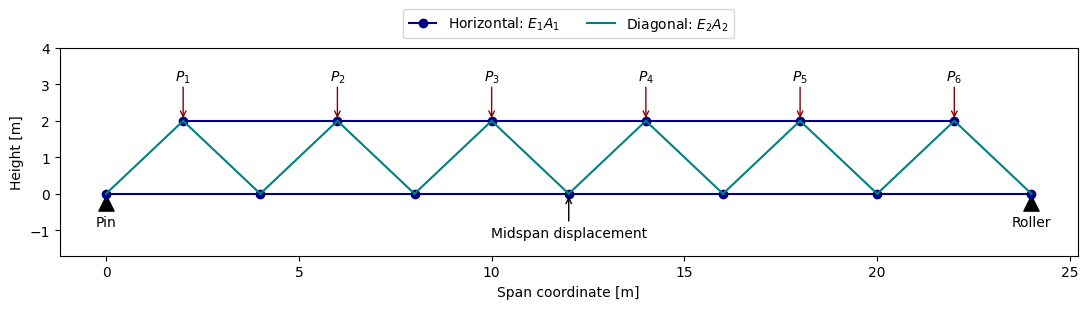

In [2]:
bottom = np.column_stack((np.arange(0, 25, 4), np.zeros(7)))
top = np.column_stack((np.arange(2, 23, 4), np.full(6, 2)))
fig, ax = plt.subplots(figsize=(11, 3.3))
ax.plot(*bottom.T, "o-", color="navy", label="Horizontal: $E_1 A_1$")
ax.plot(*top.T, "o-", color="navy")
for i in range(6):
    ax.plot(
        [bottom[i, 0], top[i, 0], bottom[i + 1, 0]],
        [0, 2, 0],
        color="teal",
        label="Diagonal: $E_2 A_2$" if i == 0 else None,
    )
    ax.annotate(
        "",
        xy=top[i],
        xytext=(top[i, 0], 3),
        arrowprops={"arrowstyle": "->", "color": "darkred"},
    )
    ax.text(top[i, 0], 3.1, f"$P_{i + 1}$", ha="center")
ax.scatter([0, 24], [-0.25, -0.25], marker="^", s=120, color="black")
ax.text(0, -0.9, "Pin", ha="center")
ax.text(24, -0.9, "Roller", ha="center")
ax.annotate(
    "Midspan displacement",
    xy=(12, 0),
    xytext=(12, -1.2),
    ha="center",
    arrowprops={"arrowstyle": "->"},
)
ax.set(xlabel="Span coordinate [m]", ylabel="Height [m]", ylim=(-1.7, 4))
ax.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.22))
fig.tight_layout()
plt.show()


**Figure.** A simply supported 23-bar truss has a pin at the left, a roller at the right and six downward loads. The response is vertical displacement at midspan.

All ten inputs are independent. Parameters below are **physical means and standard deviations**, not log-space parameters. Gumbel means the maximum-value distribution.

| Variables | Distribution | Mean | Standard deviation | Units |
|---|---|---:|---:|---|
| $E_1,E_2$ | Lognormal | $2.1\times10^{11}$ | $2.1\times10^{10}$ | Pa |
| $A_1$ | Lognormal | $2\times10^{-3}$ | $2\times10^{-4}$ | m² |
| $A_2$ | Lognormal | $10^{-3}$ | $10^{-4}$ | m² |
| $P_1,\ldots,P_6$ | Gumbel | $5\times10^4$ | $7.5\times10^3$ | N |

For this statically determinate geometry, the unit-load method gives the downward displacement directly:

$$u=\frac{36P_1+100P_2+140P_3+140P_4+100P_5+36P_6}{E_1A_1}
+\frac{\sqrt{2}(2P_1+6P_2+10P_3+10P_4+6P_5+2P_6)}{E_2A_2}.$$

The coefficients include lengths in metres. The limit state is $g=0.12-u$ in metres; failure is $g\leq0$. Tests verify this expression against independently assembled truss stiffness matrices, including each individual load case. The expression is fast enough to make reference integration practical.

In [3]:
nominal = [2.1e11, 2.1e11, 2e-3, 1e-3, *([5e4] * 6)]
print(f"Displacement at mean inputs: {1000 * truss_deflection(*nominal):.3f} mm")
model = truss_model()
limit_state = ra.LimitState(truss_limit_state)


Displacement at mean inputs: 77.836 mm


## A reference independent of the reliability solvers

Write $u=\sum_i c_i P_i$, where $c_i=h_i/(E_1A_1)+d_i/(E_2A_2)>0$. Conditional on the stiffnesses and five loads,

$$P_f\mid(E_1A_1,E_2A_2,P_{i\ne3})
=1-F_{P_3}\left(\frac{0.12-\sum_{i\ne3}c_iP_i}{c_3}\right).$$

The two independent stiffness products are lognormal, so only seven random coordinates remain. We average the expression over scrambled Sobol points. Independent scrambles give a standard error for **numerical integration**, with no surrogate fit or PySTRA transformation involved.

The paper's Monte Carlo estimate is $1.52\times10^{-3}$ from $10^6$ samples. Its approximate binomial standard error is $3.9\times10^{-5}$; exact agreement with the printed point estimate is not expected.

In [4]:
replications = truss_reference(power=19, n_replications=8, seed=2026)
reference = replications.mean()
integration_se = replications.std(ddof=1) / np.sqrt(len(replications))
published_mc = 1.52e-3
published_se = np.sqrt(published_mc * (1 - published_mc) / 1_000_000)
print(f"Conditional integration: {reference:.7f}; replicate SE {integration_se:.2g}")
print(f"Published Monte Carlo:   {published_mc:.7f}; approximate SE {published_se:.2g}")
assert abs(reference - published_mc) < 4 * (integration_se + published_se)


Conditional integration: 0.0015180; replicate SE 2.7e-06
Published Monte Carlo:   0.0015200; approximate SE 3.9e-05


## FORM and SORM

Reusing the converged FORM analysis supplies SORM with the same design point. These are local geometric approximations; they do not carry Monte Carlo sampling intervals.

In [5]:
form = ra.FORM(model, limit_state)
form_result = form.run()
assert form_result.converged
sorm = ra.SORM(model, limit_state, form=form)
sorm.run()
assert sorm.results_valid
classical = pd.DataFrame(
    [
        {
            "Method": "FORM",
            "Published Pf": 0.76e-3,
            "PySTRA Pf": form_result.failure_probability,
        },
        {
            "Method": "SORM (Breitung)",
            "Published Pf": np.nan,
            "PySTRA Pf": float(sorm.pf2_breitung),
        },
        {
            "Method": "SORM (modified Breitung)",
            "Published Pf": 1.63e-3,
            "PySTRA Pf": float(sorm.pf2_breitung_m),
        },
    ]
).set_index("Method")
classical["PySTRA relative error vs integration"] = (
    classical["PySTRA Pf"] / reference - 1
)
classical


,Published Pf,PySTRA Pf,PySTRA relative error vs integration
Method,,,
FORM,0.00076,0.000757,-0.501460
SORM (Breitung),NaN,0.001519,0.000435
SORM (modified Breitung),0.00163,0.001631,0.074279


FORM reproduces the paper's rounded result and substantially underestimates failure probability. Curve-fitting **modified Breitung (Hohenbichler–Rackwitz)** SORM also matches the published value at its printed precision. The unmodified Breitung formula gives a different approximation. This numerical match does not establish which SORM formula the paper used: the manuscript does not specify it. Stating the formula makes the comparison reproducible.

## Adaptive sparse PCE: an explicitly specified variant

This run uses a normal-coordinate Latin hypercube with 60 initial points, adaptive degree 1–5, q=0.75, at most two interacting variables, bootstrap spread, single-point U enrichment and combined beta-band/beta-stability stopping. The final probability uses 400,000 fresh surrogate classifications.

The paper instead uses 30 initial points sampled uniformly in a ball, degrees 1–10, three-point enrichment, a bootstrap classification stopping criterion and one million Monte Carlo samples. Thus this is a **PySTRA variant**, not a reproduction of its A-bPCE implementation or a comparison of computational efficiency.

In [6]:
seed = 7
analysis = ActiveLearning(
    model=truss_model(),
    limit_state=ra.LimitState(truss_limit_state),
    surrogate=PCESurrogate(
        degree=(1, 2, 3, 4, 5), q_norm=0.75, max_interaction=2, seed=seed
    ),
    n_initial=60,
    n_candidates=12_000,
    n_estimation=400_000,
    max_iterations=180,
    seed=seed,
    stopping_criterion=AllCriteria(
        criteria=(
            BetaBounds(consecutive=2),
            BetaStability(consecutive=2),
        )
    ),
)
result = analysis.run()
print(f"Status: {result.status}; true model evaluations: {result.n_evaluations}")
print(f"Selected degree: {analysis.surrogate_model.fit_result.degree}")
print(f"Pf: {result.failure_probability:.7f}; sampling CoV: {result.sampling_cov:.3f}")
print(f"95% interval conditional on the fitted surrogate: {result.sampling_interval}")
assert result.converged
assert abs(result.failure_probability - reference) < (
    4 * np.sqrt(reference * (1 - reference) / result.n_estimation) + 0.05 * reference
)


Status: converged; true model evaluations: 222
Selected degree: 5
Pf: 0.0016300; sampling CoV: 0.039
95% interval conditional on the fitted surrogate: (0.001507359378255104, 0.0017599479391548101)


The final binomial interval describes sampling error on the **frozen surrogate**. It does not include approximation bias. The paper's bootstrap bounds and these binomial intervals have different meanings and must not be compared as if they were interchangeable.

In [7]:
comparison = pd.DataFrame(
    [
        {"Estimate": "Paper MC", "Pf": published_mc},
        {"Estimate": "Independent integration", "Pf": reference},
        {"Estimate": "PySTRA FORM", "Pf": form_result.failure_probability},
        {"Estimate": "PySTRA SORM (Breitung)", "Pf": float(sorm.pf2_breitung)},
        {
            "Estimate": "PySTRA SORM (modified Breitung)",
            "Pf": float(sorm.pf2_breitung_m),
        },
        {"Estimate": "Paper A-bPCE", "Pf": 1.48e-3},
        {"Estimate": "PySTRA active PCE variant", "Pf": result.failure_probability},
    ]
).set_index("Estimate")
comparison


,Pf
Estimate,
Paper MC,0.001520
Independent integration,0.001518
PySTRA FORM,0.000757
PySTRA SORM (Breitung),0.001519
PySTRA SORM (modified Breitung),0.001631
Paper A-bPCE,0.001480
PySTRA active PCE variant,0.001630


## Check classifications independently

A close probability can hide false positives cancelled by false negatives. Evaluate the actual physical limit state at fresh independent standard-normal points and compare signs with the fitted surrogate. These validation calls are additional to the learning budget reported above; this is affordable because the truss has an analytical response.

In [8]:
points = np.random.default_rng(892).normal(size=(200_000, 10))
# Build physical inputs independently of PySTRA's probability transformation.
variance = np.log1p(0.1**2)
properties = np.exp(
    np.log([2.1e11, 2.1e11, 2e-3, 1e-3])
    - variance / 2
    + np.sqrt(variance) * points[:, :4]
)
scale = 7.5e3 * np.sqrt(6) / np.pi
loads = gumbel_r.ppf(
    norm.cdf(points[:, 4:]), loc=5e4 - np.euler_gamma * scale, scale=scale
)
truth = truss_limit_state(*properties.T, *loads.T) <= 0
prediction = analysis.surrogate_model.predict(points)[0] <= 0
false_negative = np.mean(truth & ~prediction)
false_positive = np.mean(~truth & prediction)
print(f"Missed-failure mass / reference Pf: {false_negative / reference:.2%}")
print(f"False-positive mass / reference Pf: {false_positive / reference:.2%}")
assert false_negative + false_positive < 0.1 * reference


Missed-failure mass / reference Pf: 0.66%
False-positive mass / reference Pf: 0.99%


The regression suite repeats the active analysis with seeds 7, 23 and 101. It checks convergence, probability error with an explicit sampling allowance, classification error and model-evaluation budget. This benchmark can be reused as further reliability algorithms are added; the paper's physical definition and the independent reference remain fixed.

## Interpretation

Keep mechanical-model verification, probability estimation and surrogate classification checks separate. Include the independent validation cost when budgeting an engineering study.

**Continue:** [User guide](../active_learning.rst) · [API reference](../api/active_learning.rst) · [Theory](../theory/active_learning.rst)